# Spring 2026 CMSC320 Final Project: ⚛






Team Members:

Saisha Pitani: I worked on the final tutorial report creation including structuring and formatting. Additionally, I worked on the dataset curation and preprocessing section gathering and cleaning data.


Pari Gill


Alex Emmert: I worked on the exploratory data analysis section.


Christopher Liu

# Part 1 - Introduction: ✅


Social media has become a major part of everyday life, influencing communication, entertainment, shopping habits, mental health, and lifestyle. Different platforms such as Instagram, TikTok, Facebook, and Twitter generate massive amounts of user activity data that can be analyzed to better understand human behavior. We analyzed the “Social Media User Analysis” dataset from Kaggle, which contains user profiles with demographic, behavioral, and lifestyle information in correlation to social media usage.

The main goal of this analysis is to explore how different factors such as age, gender, lifestyle habits, screen time, and engagement relate to social media behavior. We aim to answer questions such as:


Is there a relationship between engagement levels and lifestyle or health-related factors?

Can user behavior patterns help predict high engagement or heavy social media usage?

Answering these questions is important because social media affects both individuals and businesses in significant ways. Companies and marketers can use these insights to better understand user engagement and improve digital marketing strategies. Researchers and educators can study how online behavior connects to lifestyle habits and well-being.  By using data analysis and machine learning techniques, this project aims to uncover meaningful trends and provide insights into how individuals interact with social media in the  digital world.

# Part 2: Data curation: ⌨




Source: The dataset used in this project is the “Social Media User Analysis” dataset available on Kaggle. The dataset contains over one million synthetic social media user records designed to simulate real-world user behavior across multiple platforms. Each entry includes demographic information, engagement, lifestyle factors, and usage patterns based on platforms. The dataset was created for educational and analytical purposes, making it useful for data science and machine learning projects without exposing sensitive user information.


Source Link: https://www.kaggle.com/datasets/rockyt07/social-media-user-analysis



Here are the features included within the dataset:



*   Age
*   Location

*   Gender

*   Social media platform
*   Daily Screen Time


*   Number of posts , comments, followers, likes

*   Lifestyle habits
*   Engagement metrics













Importing and Condensing: The dataset originally had 1,000,000 entries. In order to upload the file to GitHub, we cut the data down to 90,000 lines. Since the dataset has so many entries, we think this might slow down the training time of our ML Model, so we decided to condense our dataset, using about 200 random samples.

In [6]:
import pandas as pd
df = pd.read_csv("https://raw.githubusercontent.com/saishapitani/cmsc320GroupProj/refs/heads/main/instagram_usage_lifestyle.csv")
df = df.sample(n=200, random_state=42)
df.head()


,user_id,app_name,age,gender,country,urban_rural,income_level,employment_status,education_level,relationship_status,...,last_login_date,average_session_length_minutes,content_type_preference,preferred_content_theme,privacy_setting_level,two_factor_auth_enabled,biometric_login_used,linked_accounts_count,subscription_status,user_engagement_score
54759,54760,Instagram,57,Female,Other,Rural,High,Retired,High school,Single,...,2025-10-09,33.0,Mixed,Fitness,Private,Yes,Yes,2,Free,1.10
12456,12457,Instagram,44,Female,United Kingdom,Suburban,Middle,Full-time employed,Bachelor’s,In a relationship,...,2025-03-14,21.1,Photos,Other,Friends only,Yes,Yes,4,Premium,1.01
53401,53402,Instagram,57,Male,India,Suburban,Middle,Full-time employed,Bachelor’s,Single,...,2025-11-24,21.5,Photos,Tech,Public,Yes,Yes,4,Free,1.25
62903,62904,Instagram,53,Female,Canada,Urban,Low,Student,Bachelor’s,Single,...,2025-12-17,8.9,Live,Tech,Friends only,No,No,3,Free,1.03
66338,66339,Instagram,19,Female,Australia,Rural,Middle,Student,High school,In a relationship,...,2025-01-05,12.9,Reels,Tech,Friends only,Yes,Yes,3,Free,1.46


# Part 3: Exploratory Data Analysis

Here we want to get a rough impression of how our data is shaped, especially the elements that our machine learning model will be focused on. There is a *lot* of data here (58 columns total!) so it's unlikely that we'll be able to look at all of the possible factors.

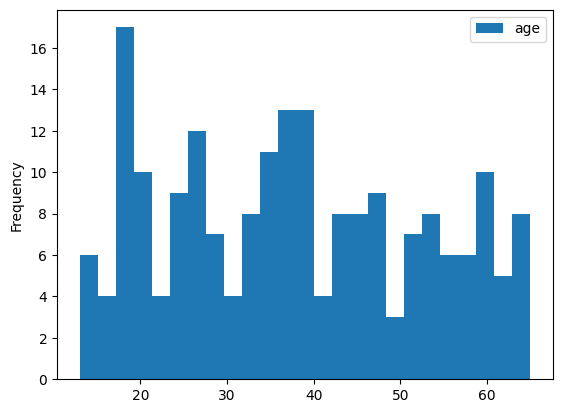

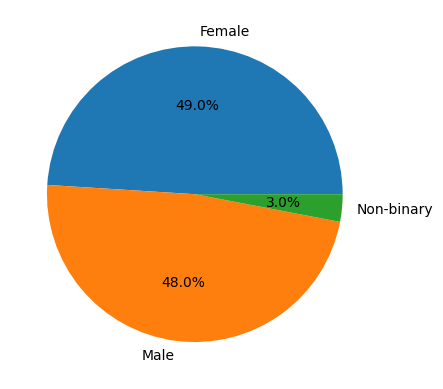

In [53]:
import matplotlib.pyplot as plt

#print(df.columns)

# Let's look at the ages & genders of the participants
df.plot.hist(column=['age'], bins=25)
plt.show()

df['gender'].value_counts().plot.pie(autopct='%1.1f%%', ylabel='')
plt.show()



Ok! Ages look fairly evenly distributed from teenagers to mid-60s, with a few spikes here and there. Gender is approximately representative of the population. Now, let's look at how age correlates with average session time and number of accounts!

<Axes: xlabel='age', ylabel='linked_accounts_count'>

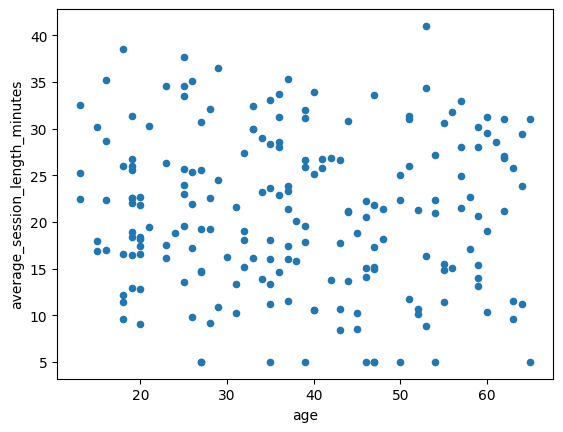

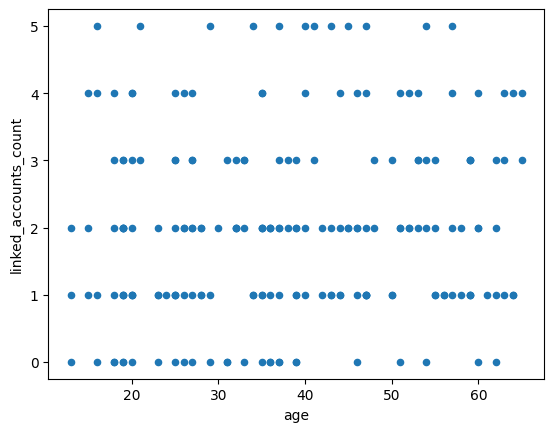

In [54]:

df.plot(kind='scatter', x='age', y='average_session_length_minutes')
df.plot(kind='scatter', x='age', y='linked_accounts_count')

Neat! Again, not looking like any strong correlations here. This dataset seems fairly homogenous.

Now, let's see how the number of follow*ers* interacts with the number of users each person is follow*ing* - we might expect to see a correlation here as more usage of social media will lead ot both more followers & following more accounts.

<Axes: xlabel='followers_count', ylabel='following_count'>

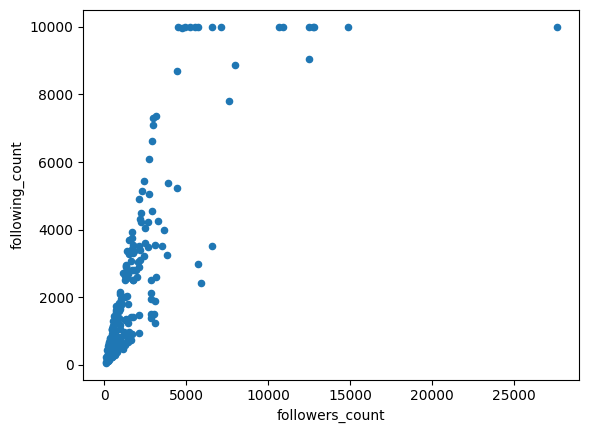

In [55]:

df.plot(kind='scatter', x='followers_count', y='following_count')

Ok, looks like a pretty strong correlation! The more followers a user has, the more people they tend to be following.

Finally, let's look at stress: are users who are more stressed more likely to use social media? This is a narrative that is often presented in popular media, but we want to determine whether it shows up here in our dataset.

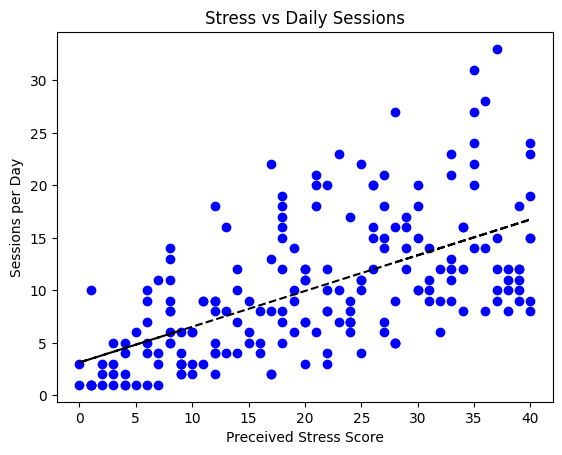

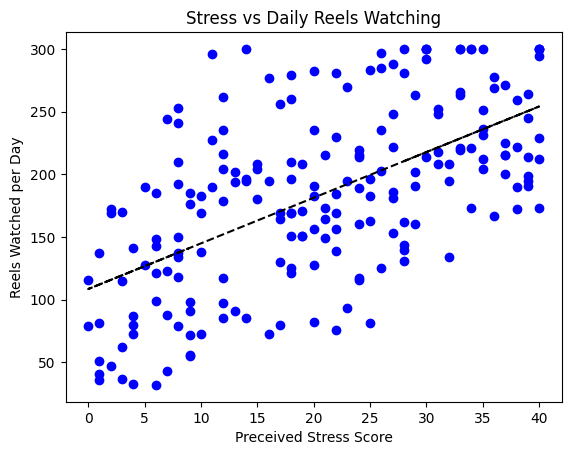

In [52]:
import numpy as np

#df.plot(kind='scatter', x='perceived_stress_score', y='sessions_per_day')
#df.plot(kind='scatter', x='perceived_stress_score', y='reels_watched_per_day')

# ^^ these showed correlations, so let's use linear regression here!

coef = np.polyfit(df["perceived_stress_score"],df["sessions_per_day"],1)
poly1d_fn = np.poly1d(coef)
plt.plot(df["perceived_stress_score"],df["sessions_per_day"], "bo", df["perceived_stress_score"], poly1d_fn(df["perceived_stress_score"]), '--k')

plt.title("Stress vs Daily Sessions")
plt.xlabel("Preceived Stress Score")
plt.ylabel("Sessions per Day")
plt.show()

coef = np.polyfit(df["perceived_stress_score"],df["reels_watched_per_day"],1)
poly1d_fn = np.poly1d(coef)
plt.plot(df["perceived_stress_score"],df["reels_watched_per_day"], "bo", df["perceived_stress_score"], poly1d_fn(df["perceived_stress_score"]), '--k')

plt.title("Stress vs Daily Reels Watching")
plt.xlabel("Preceived Stress Score")
plt.ylabel("Reels Watched per Day")
plt.show()

Ok, those are some neat correlations! Now we have some data we can work with for the ML portion of the project.